# 03. Exploratory Data Analysis & Feature Extraction

This notebook loads the raw scaled YouTube dataset of 8 niches, runs the upgraded `YouTubeFeatureExtractor` to calculate rolling baselines, chronological sequences, and format styles, profiles outliers, and generates insights.

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': [11, 6], 'font.size': 11})

sys.path.append('..')
from src.features import YouTubeFeatureExtractor

In [ ]:
# Load the scaled dataset
raw_path = '../data/raw/scaled_niche/videos.csv'
if not os.path.exists(raw_path):
    raise FileNotFoundError(f"Dataset not found at {raw_path}. Run harvester first.")

df_raw = pd.read_csv(raw_path)
print(f"Loaded {len(df_raw)} videos from {df_raw['channel_id'].nunique()} channels.")
print(f"Columns: {list(df_raw.columns)}")
print(f"Niches represented: {df_raw['niche'].value_counts() if 'niche' in df_raw.columns else 'None'}")

Loaded 28314 videos from 80 channels.
Columns: ['video_id', 'channel_id', 'channel_title', 'title', 'description', 'tags', 'published_at', 'duration', 'view_count', 'like_count', 'comment_count', 'channel_subscriber_count', 'channel_total_videos', 'channel_total_views', 'channel_created', 'niche', 'channel_category']
Niches represented: niche
gaming                  4681
vlogging_lifestyle      4023
makeup_beauty           3713
education_science       3542
tech_gadgets            3518
personal_finance        3505
geopolitics_economy     3502
comedy_entertainment    1830
Name: count, dtype: int64


In [ ]:
# Run Feature Extraction
extractor = YouTubeFeatureExtractor()
extractor.fit(df_raw)
df_feat = extractor.transform(df_raw)

print("✅ Features extracted successfully!")
print(f"Features shape: {df_feat.shape}")

✅ Features extracted successfully!
Features shape: (28314, 63)


In [ ]:
# Save processed features
out_dir = '../data/processed/scaled_niche'
os.makedirs(out_dir, exist_ok=True)
features_path = os.path.join(out_dir, 'features.csv')
df_feat.to_csv(features_path, index=False)
print(f"✅ Processed features saved to: {features_path}")

✅ Processed features saved to: ../data/processed/scaled_niche\features.csv


## 1. Niche Analysis: Median Views & Subscribers

=== Niche Performance Summary ===
               niche  video_count  median_views  median_likes
comedy_entertainment         1830      344688.0        4548.5
   education_science         3542      824268.0       32341.0
              gaming         4681      143626.0        8606.0
 geopolitics_economy         3502       13895.5         374.0
       makeup_beauty         3713       35349.0         980.0
    personal_finance         3505        3380.0         117.0
        tech_gadgets         3518      276155.0        9413.0
  vlogging_lifestyle         4023      210472.0        7254.0


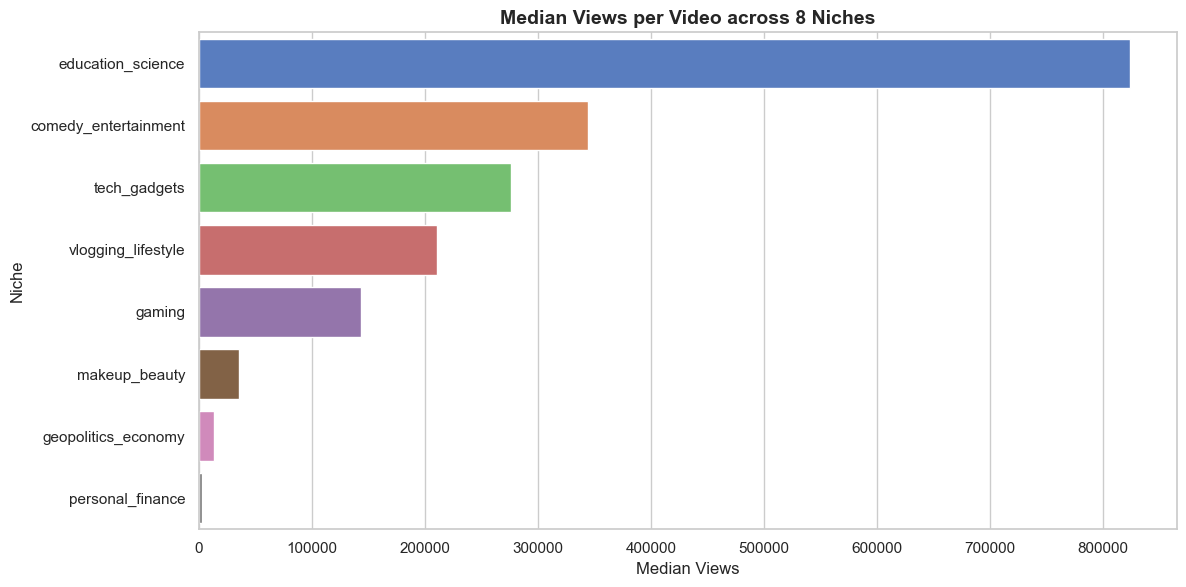

In [ ]:
# Group by niche and show median views and subscribers
niche_stats = df_raw.groupby('niche').agg(
    video_count=('video_id', 'count'),
    median_views=('view_count', 'median'),
    median_likes=('like_count', 'median')
).reset_index()

print("=== Niche Performance Summary ===")
print(niche_stats.to_string(index=False))

# Plot Median Views per Niche
plt.figure(figsize=(12, 6))
sns.barplot(data=niche_stats.sort_values('median_views', ascending=False), x='median_views', y='niche', hue='niche', legend=False)
plt.title('Median Views per Video across 8 Niches', fontsize=14, fontweight='bold')
plt.xlabel('Median Views')
plt.ylabel('Niche')
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/niche_median_views.png', dpi=150)
plt.show()

## 2. Long-Form vs Shorts Duration Profile

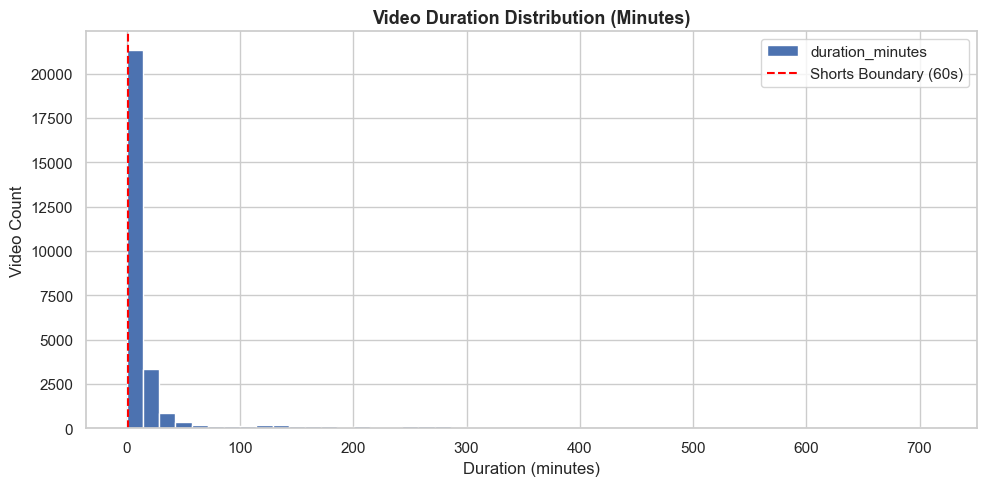

Shorts (<=60s) representation: 34.18%


In [ ]:
plt.figure(figsize=(10, 5))
df_feat['duration_minutes'].plot(kind='hist', bins=50, color='#4C72B0', edgecolor='white')
plt.axvline(1.0, color='red', linestyle='--', label='Shorts Boundary (60s)')
plt.title('Video Duration Distribution (Minutes)', fontsize=13, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Video Count')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/duration_distribution.png', dpi=150)
plt.show()

shorts_pct = (df_feat['is_shorts'].mean() * 100)
print(f"Shorts (<=60s) representation: {shorts_pct:.2f}%")

## 3. Engagement Rate by Channel Category (Successful vs Small)

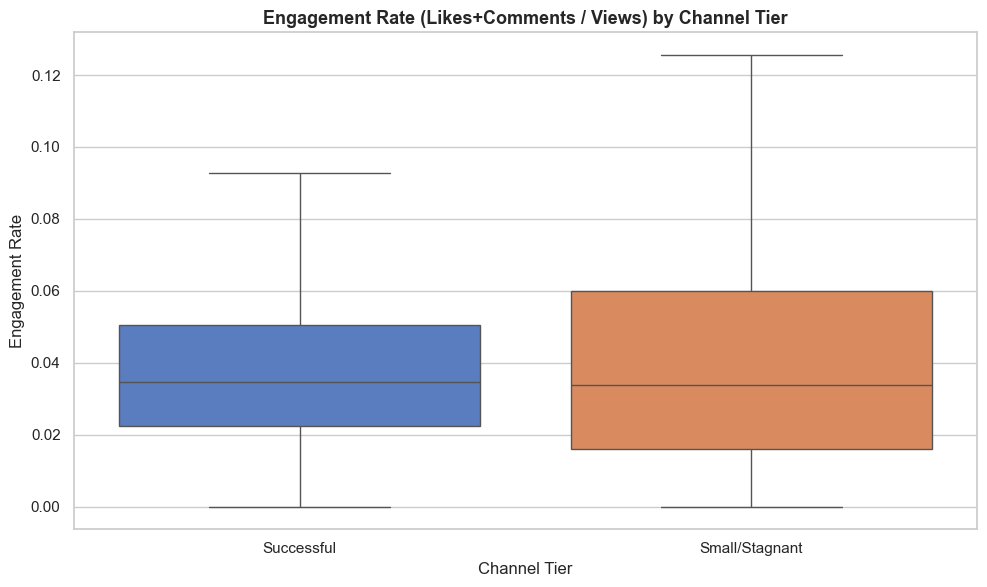

channel_category
Small/Stagnant    0.033791
Successful        0.034696
Name: engagement_rate, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_feat, x='channel_category', y='engagement_rate', showfliers=False, hue='channel_category', legend=False)
plt.title('Engagement Rate (Likes+Comments / Views) by Channel Tier', fontsize=13, fontweight='bold')
plt.xlabel('Channel Tier')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.savefig('../reports/engagement_rate_by_tier.png', dpi=150)
plt.show()

print(df_feat.groupby('channel_category')['engagement_rate'].median())

## 4. Feature Correlations with Log Views

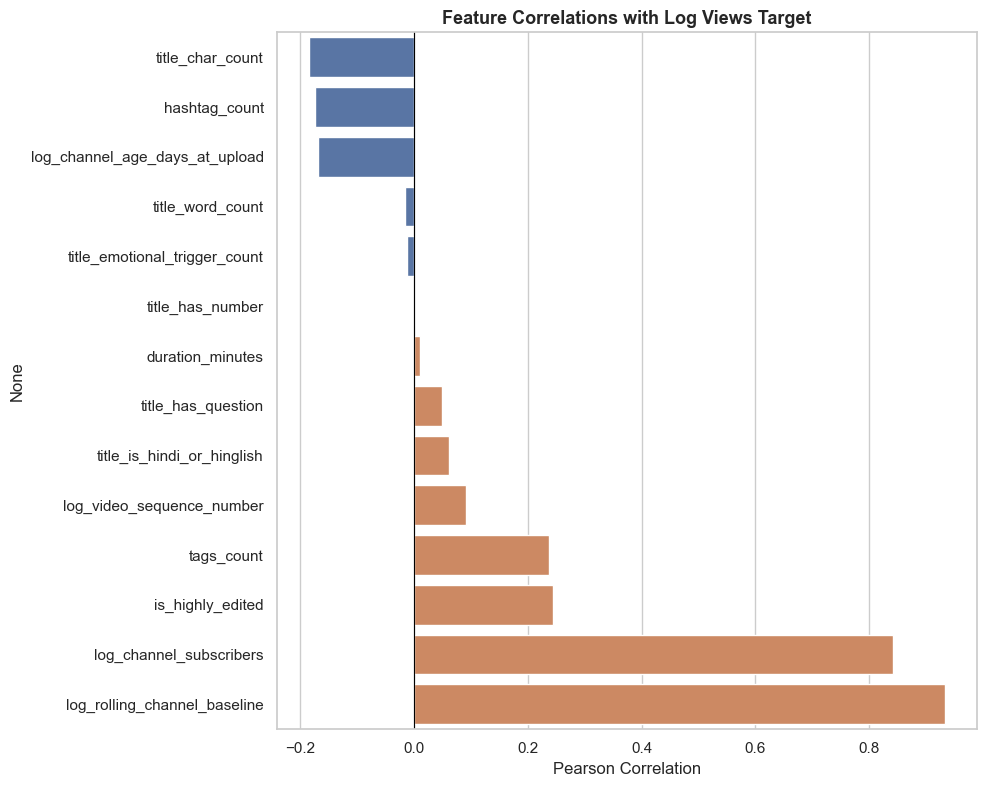

In [ ]:
corr_features = [
    'duration_minutes', 'title_char_count', 'title_word_count',
    'title_has_number', 'title_has_question', 'title_emotional_trigger_count',
    'title_is_hindi_or_hinglish', 'tags_count', 'hashtag_count',
    'log_channel_subscribers', 'log_rolling_channel_baseline',
    'log_video_sequence_number', 'log_channel_age_days_at_upload',
    'is_highly_edited', 'log_views'
]
corr_features = [f for f in corr_features if f in df_feat.columns]
correlations = df_feat[corr_features].corr()['log_views'].drop('log_views').sort_values()

plt.figure(figsize=(10, 8))
colors = ['#DD8452' if x > 0 else '#4C72B0' for x in correlations.values]
sns.barplot(x=correlations.values, y=correlations.index, palette=colors, hue=correlations.index, legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlations with Log Views Target', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('../reports/feature_correlations.png', dpi=150)
plt.show()